# Evaluate Embedding Models — Zero-Shot Baseline

Compare top sentence-embedding models on `ZSHOT-HARDSET-v2` test set using cosine similarity as the zero-shot classification score.

Models evaluated:
- `OrdalieTech/Solon-embeddings-large-0.1`
- `Lajavaness/bilingual-embedding-large`
- `jinaai/jina-embeddings-v5-text-small`
- `microsoft/harrier-oss-v1-0.6b`
- `intfloat/e5-large-v2`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sentence_transformers import SentenceTransformer
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm.auto import tqdm

from gliznet.data import load_dataset
from gliznet.metrics import _ndcg_at_k, _sigmoid

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
KS = (1, 3, 5, 10)

MODELS = [
    "OrdalieTech/Solon-embeddings-large-0.1",
    # "Lajavaness/bilingual-embedding-large",
    "jinaai/jina-embeddings-v5-text-small",
    "microsoft/harrier-oss-v1-0.6b",
    "intfloat/e5-large-v2",
]

# GliZNet reference scores (checkpoint-850) for the final comparison table
GLIZNET_REF = {
    "MRR": 0.966, "Hit@1": 0.935, "Hit@3": 0.985, "Hit@5": 1.000, "NDCG@10": 0.942,
    "ROC-AUC": 0.8251, "Avg Precision": 0.8744,
}

print(f"Device: {DEVICE}")
print(f"Models to evaluate: {len(MODELS)}")

Device: cuda
Models to evaluate: 4


In [2]:
test_ds = load_dataset(
    path="alexneakameni/ZSHOT-HARDSET-v2",
    split="test",
    shuffle_labels=False,
    min_label_length=3,
)
print(f"✓ Test set: {len(test_ds)} samples")
print(f"  Columns: {test_ds.column_names}")
ex = test_ds[0]
print(f"\nSample:")
print(f"  text   : {ex['text'][:120]}...")
print(f"  labels : {ex['ltext']}")
print(f"  targets: {ex['lint']}")

✓ Test set: 1322 samples
  Columns: ['text', 'ltext', 'lint']

Sample:
  text   : All mineral resources within Eswatini remain under the ownership of the iNgwenyama, with the sole exception of deposits ...
  labels : ['constitutional_limitation', 'ownership_claim', 'resource_control', 'ceremonial_ritual', 'ritual_purification', 'succession_criteria']
  targets: [1, 1, 1, 0, 0, 0]


In [3]:
def compute_ranking_metrics(records, ks=KS):
    """Compute Hit@k, NDCG@k, MRR, ROC-AUC, Avg Precision from a list of records."""
    hits  = {k: [] for k in ks}
    ndcgs = {k: [] for k in ks}
    rr, aucs, aps = [], [], []

    for r in records:
        s = np.array(r["scores"], dtype=float)
        g = np.array(r["targets"], dtype=float)
        if g.sum() == 0:
            continue

        ranked = g[np.argsort(-s)]
        for k in ks:
            hits[k].append(float(ranked[:k].any()))
            ndcgs[k].append(_ndcg_at_k(ranked, k))

        pos_ranks = np.where(ranked > 0.5)[0]
        rr.append(1.0 / (pos_ranks[0] + 1) if len(pos_ranks) else 0.0)

        if len(np.unique(g)) > 1:
            probs = _sigmoid(s)
            try:
                aucs.append(roc_auc_score(g, probs))
                aps.append(average_precision_score(g, probs))
            except ValueError:
                pass

    out = {}
    for k in ks:
        out[f"Hit@{k}"]  = np.mean(hits[k])
        out[f"NDCG@{k}"] = np.mean(ndcgs[k])
    out["MRR"]           = np.mean(rr)
    out["ROC-AUC"]       = np.mean(aucs)  if aucs else float("nan")
    out["Avg Precision"] = np.mean(aps)   if aps  else float("nan")
    out["N"]             = len(rr)
    return out


def encode_batch(model, texts, batch_size=64, prompt=None, **encode_kwargs):
    """Encode a list of strings with optional prompt prefix and extra kwargs forwarded to model.encode()."""
    all_embs = []
    for i in range(0, len(texts), batch_size):
        chunk = texts[i : i + batch_size]
        if prompt:
            chunk = [f"{prompt}{t}" for t in chunk]
        embs = model.encode(
            chunk,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
            **encode_kwargs,
        )
        all_embs.append(embs)
    return np.vstack(all_embs)


print("✓ Helpers defined")

✓ Helpers defined


In [4]:
all_results = {}   # model_name -> metrics dict

# e5 and harrier use query/passage prompt prefixes
E5_QUERY_PROMPT   = "query: "
E5_PASSAGE_PROMPT = "passage: "

for model_name in MODELS:
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*60}")

    model = SentenceTransformer(model_name, device=DEVICE, trust_remote_code=True)

    name_lower = model_name.lower()
    use_e5_prompt  = "e5" in name_lower or "harrier" in name_lower
    use_jina_task  = "jina" in name_lower   # requires task= kwarg

    texts       = test_ds["text"]
    labels_list = test_ds["ltext"]
    gts_list    = test_ds["lint"]

    # Extra kwargs for jina models
    text_encode_kw  = {"task": "retrieval"} if use_jina_task else {}
    label_encode_kw = {"task": "retrieval"} if use_jina_task else {}

    # Encode all texts once
    text_prompt = E5_QUERY_PROMPT if use_e5_prompt else None
    print("  Encoding texts…")
    text_embs = encode_batch(model, texts, prompt=text_prompt, **text_encode_kw)  # (N, D)

    # Collect all label spans to encode in one pass
    all_labels = []
    label_offsets = []  # (start, end) per sample
    for lbls in labels_list:
        label_offsets.append((len(all_labels), len(all_labels) + len(lbls)))
        all_labels.extend(lbls)

    label_prompt = E5_PASSAGE_PROMPT if use_e5_prompt else None
    print(f"  Encoding {len(all_labels):,} label spans…")
    label_embs = encode_batch(model, all_labels, prompt=label_prompt, **label_encode_kw)  # (M, D)

    # Compute cosine sim (already L2-normalised → dot product = cosine)
    records = []
    for i, (gt_labels, gt_ints) in enumerate(zip(labels_list, gts_list)):
        start, end = label_offsets[i]
        lbl_e  = label_embs[start:end]            # (K, D)
        txt_e  = text_embs[i : i + 1]             # (1, D)
        scores = (txt_e @ lbl_e.T).squeeze(0).tolist()  # (K,)

        records.append({
            "scores":  scores,
            "targets": gt_ints,
        })

    metrics = compute_ranking_metrics(records)
    all_results[model_name.split("/")[-1]] = metrics

    print(f"  MRR={metrics['MRR']:.4f}  Hit@1={metrics['Hit@1']:.4f}  Hit@5={metrics['Hit@5']:.4f}  NDCG@10={metrics['NDCG@10']:.4f}")

    # Free GPU memory
    del model
    torch.cuda.empty_cache()

print("\n✓ All embedding models evaluated")


Evaluating: OrdalieTech/Solon-embeddings-large-0.1


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Encoding texts…
  Encoding 9,979 label spans…
  MRR=0.9143  Hit@1=0.8427  Hit@5=1.0000  NDCG@10=0.8946

Evaluating: jinaai/jina-embeddings-v5-text-small


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

...

  Encoding texts…
  Encoding 9,979 label spans…
  MRR=0.9364  Hit@1=0.8828  Hit@5=1.0000  NDCG@10=0.9136

Evaluating: microsoft/harrier-oss-v1-0.6b


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  Encoding texts…
  Encoding 9,979 label spans…
  MRR=0.9145  Hit@1=0.8404  Hit@5=1.0000  NDCG@10=0.8967

Evaluating: intfloat/e5-large-v2


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Encoding texts…
  Encoding 9,979 label spans…
  MRR=0.9305  Hit@1=0.8714  Hit@5=1.0000  NDCG@10=0.9109

✓ All embedding models evaluated


In [ ]:
# Add GliZNet reference row
all_results["GliZNet (ours)"] = GLIZNET_REF

df = pd.DataFrame(all_results).T
# Select key columns for display
cols = ["MRR", "Hit@1", "Hit@3", "Hit@5", "NDCG@10", "ROC-AUC", "Avg Precision"]
df_display = df[[c for c in cols if c in df.columns]].astype(float).round(4)

# Highlight best per column (excluding GliZNet for fair comparison)
print("=" * 70)
print("  RESULTS — Ranking Metrics on ZSHOT-HARDSET-v2 test set (N=1,322)")
print("=" * 70)
print(df_display.to_string())

  RESULTS — Ranking Metrics on ZSHOT-HARDSET-v2 test set (N=1,322)
                                  MRR   Hit@1   Hit@3  Hit@5  NDCG@10  ROC-AUC  Avg Precision
Solon-embeddings-large-0.1     0.9143  0.8427  0.9894    1.0   0.8946   0.7081         0.7996
jina-embeddings-v5-text-small  0.9364  0.8828  0.9947    1.0   0.9136   0.7586         0.8316
harrier-oss-v1-0.6b            0.9145  0.8404  0.9917    1.0   0.8967   0.7163         0.8040
e5-large-v2                    0.9305  0.8714  0.9939    1.0   0.9109   0.7529         0.8281
GliZNet (ours)                 0.9660  0.9350  0.9850    1.0   0.9420   0.8251         0.8744


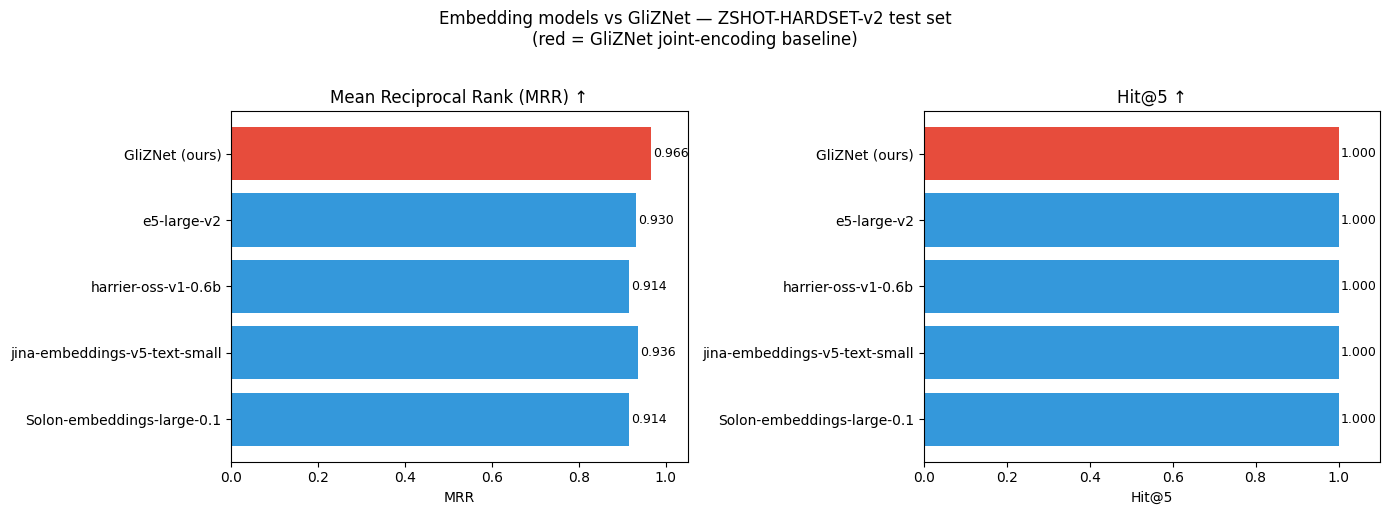

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_plot = list(df_display.index)
colors = ["#e74c3c" if m == "GliZNet (ours)" else "#3498db" for m in models_plot]

# MRR bar chart
axes[0].barh(models_plot, df_display["MRR"], color=colors)
axes[0].set_xlabel("MRR"); axes[0].set_title("Mean Reciprocal Rank (MRR) ↑")
axes[0].set_xlim(0, 1.05)
for i, v in enumerate(df_display["MRR"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

# Hit@5 bar chart
axes[1].barh(models_plot, df_display["Hit@5"], color=colors)
axes[1].set_xlabel("Hit@5"); axes[1].set_title("Hit@5 ↑")
axes[1].set_xlim(0, 1.1)
for i, v in enumerate(df_display["Hit@5"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Embedding models vs GliZNet — ZSHOT-HARDSET-v2 test set\n(red = GliZNet joint-encoding baseline)", y=1.02)
plt.tight_layout()
plt.show()